Banking Project

PRN: Shravani Pawar (24070243039)

    Shalvi Pande (24070243036)

In [1]:
# Loan Default Prediction - Notebook
# Purpose: EDA, preprocessing, modelling, evaluation, feature-importance and recommendations
# Run: Python 3.8+; recommended packages listed below

!pip install -q pandas numpy matplotlib seaborn scikit-learn xgboost imbalanced-learn shap



[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


Imports and settings

In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import (confusion_matrix, classification_report, roc_auc_score,
                             roc_curve, precision_recall_curve, accuracy_score, f1_score, precision_score, recall_score)

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb

# Imbalance
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# plot style
sns.set(style="whitegrid")
%matplotlib inline


Load data

In [3]:

DATA_PATH = "loan_default.csv"
df = pd.read_csv(DATA_PATH)
df.shape, df.columns


((255347, 18),
 Index(['LoanID', 'Age', 'Income', 'LoanAmount', 'CreditScore',
        'MonthsEmployed', 'NumCreditLines', 'InterestRate', 'LoanTerm',
        'DTIRatio', 'Education', 'EmploymentType', 'MaritalStatus',
        'HasMortgage', 'HasDependents', 'LoanPurpose', 'HasCoSigner',
        'Default'],
       dtype='object'))

Quick peek & target check

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 255347 entries, 0 to 255346
Data columns (total 18 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   LoanID          255347 non-null  object 
 1   Age             255347 non-null  int64  
 2   Income          255347 non-null  int64  
 3   LoanAmount      255347 non-null  int64  
 4   CreditScore     255347 non-null  int64  
 5   MonthsEmployed  255347 non-null  int64  
 6   NumCreditLines  255347 non-null  int64  
 7   InterestRate    255347 non-null  float64
 8   LoanTerm        255347 non-null  int64  
 9   DTIRatio        255347 non-null  float64
 10  Education       255347 non-null  object 
 11  EmploymentType  255347 non-null  object 
 12  MaritalStatus   255347 non-null  object 
 13  HasMortgage     255347 non-null  object 
 14  HasDependents   255347 non-null  object 
 15  LoanPurpose     255347 non-null  object 
 16  HasCoSigner     255347 non-null  object 
 17  Default   

In [5]:
df.head(5)
#Description: Inspect first rows to see column names and sample values.

,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,I38PQUQS96,56,85994,50587,520,80,4,15.23,36,0.44,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes,0
1,HPSK72WA7R,69,50432,124440,458,15,1,4.81,60,0.68,Master's,Full-time,Married,No,No,Other,Yes,0
2,C1OZ6DPJ8Y,46,84208,129188,451,26,3,21.17,24,0.31,Master's,Unemployed,Divorced,Yes,Yes,Auto,No,1
3,V2KKSFM3UN,32,31713,44799,743,0,3,7.07,24,0.23,High School,Full-time,Married,No,No,Business,No,0
4,EY08JDHTZP,60,20437,9139,633,8,4,6.51,48,0.73,Bachelor's,Unemployed,Divorced,No,Yes,Auto,No,0


Check Target Column

In [6]:
target_col = "Default"

print(df[target_col].value_counts())
print(df[target_col].value_counts(normalize=True))


Default
0    225694
1     29653
Name: count, dtype: int64
Default
0    0.883872
1    0.116128
Name: proportion, dtype: float64


Dataset Info & Missing Values

In [ ]:
df.describe().T
df.isnull().sum().sort_values(ascending=False)


LoanID            0
Age               0
HasCoSigner       0
LoanPurpose       0
HasDependents     0
HasMortgage       0
MaritalStatus     0
EmploymentType    0
Education         0
DTIRatio          0
LoanTerm          0
InterestRate      0
NumCreditLines    0
MonthsEmployed    0
CreditScore       0
LoanAmount        0
Income            0
Default           0
dtype: int64

Drop Duplicate Rows

In [8]:
print("Before:", df.shape)
df.drop_duplicates(inplace=True)
print("After:", df.shape)


Before: (255347, 18)
After: (255347, 18)


Identify Numerical & Categorical Columns

In [9]:
num_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_cols = df.select_dtypes(include=["object"]).columns.tolist()

num_cols.remove("Default")  # remove target from num columns

num_cols, cat_cols


(['Age',
  'Income',
  'LoanAmount',
  'CreditScore',
  'MonthsEmployed',
  'NumCreditLines',
  'InterestRate',
  'LoanTerm',
  'DTIRatio'],
 ['LoanID',
  'Education',
  'EmploymentType',
  'MaritalStatus',
  'HasMortgage',
  'HasDependents',
  'LoanPurpose',
  'HasCoSigner'])

Numerical Feature Distributions

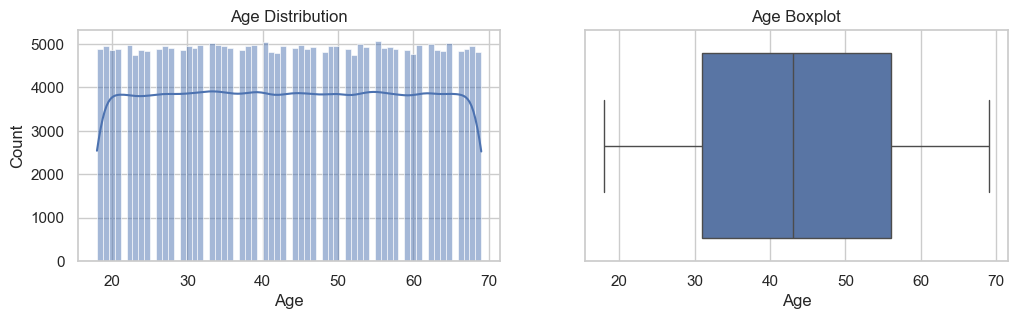

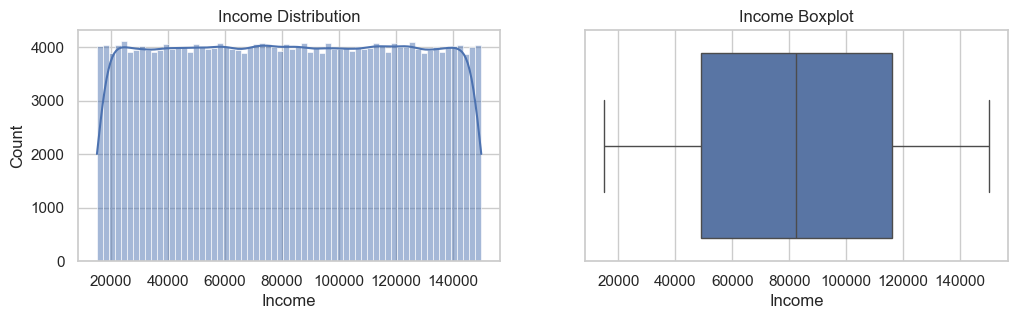

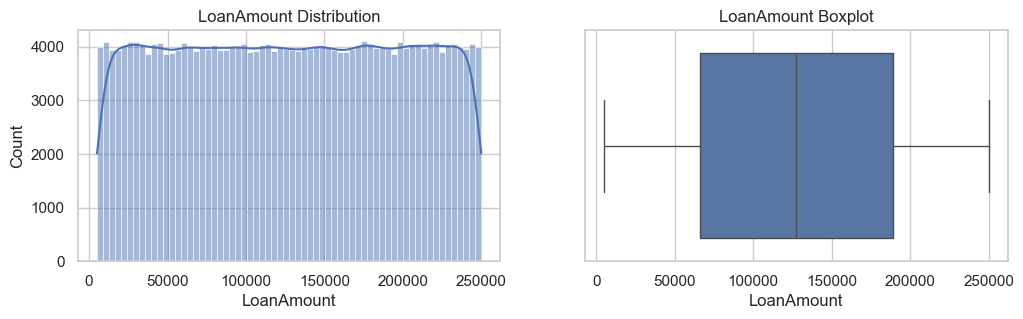

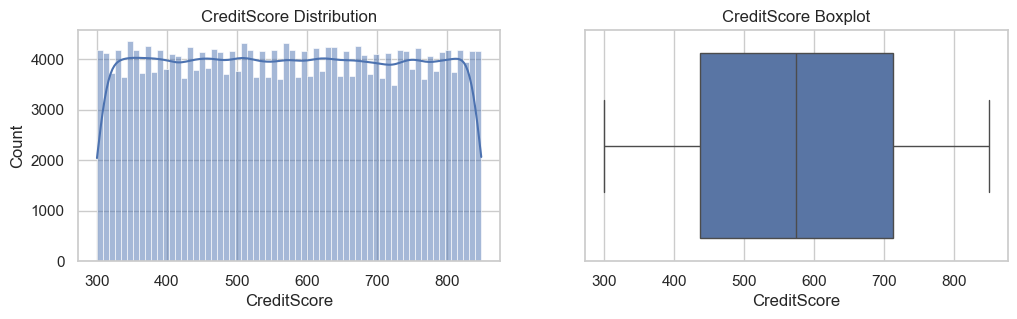

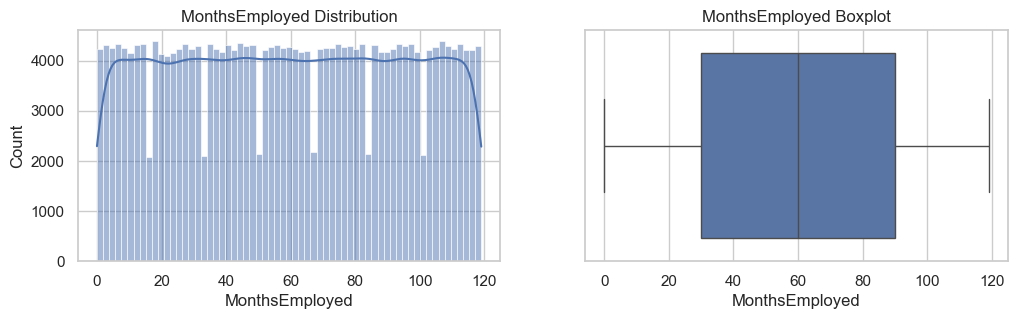

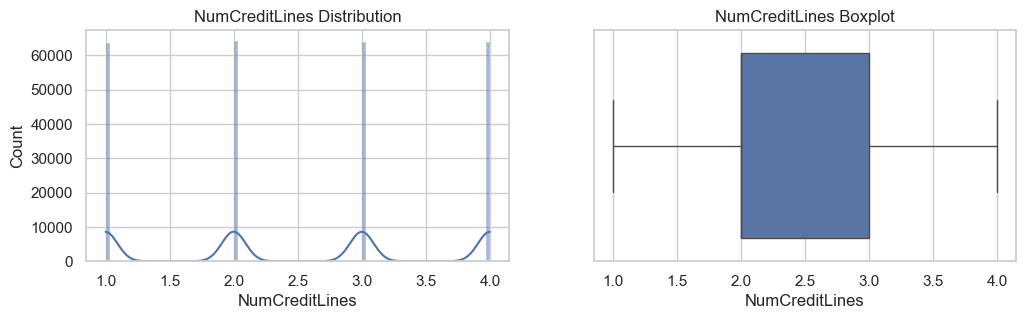

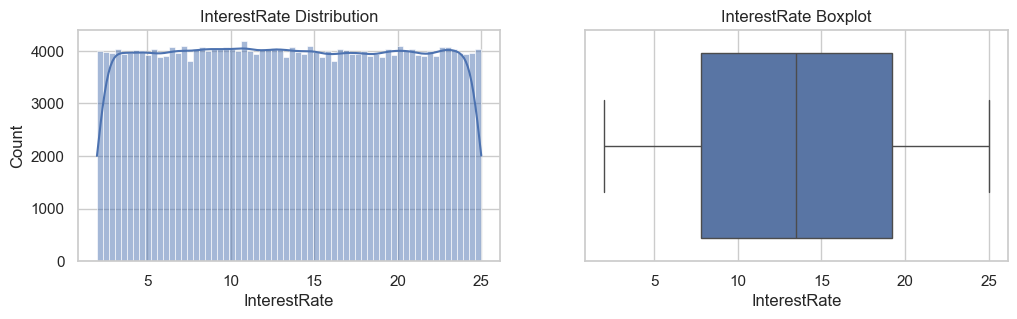

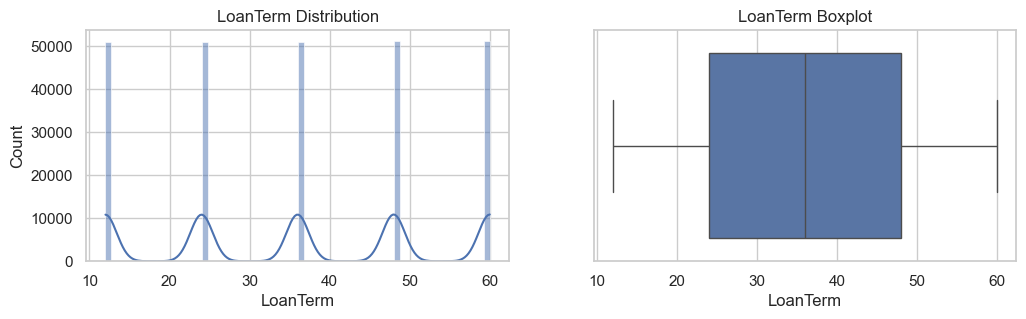

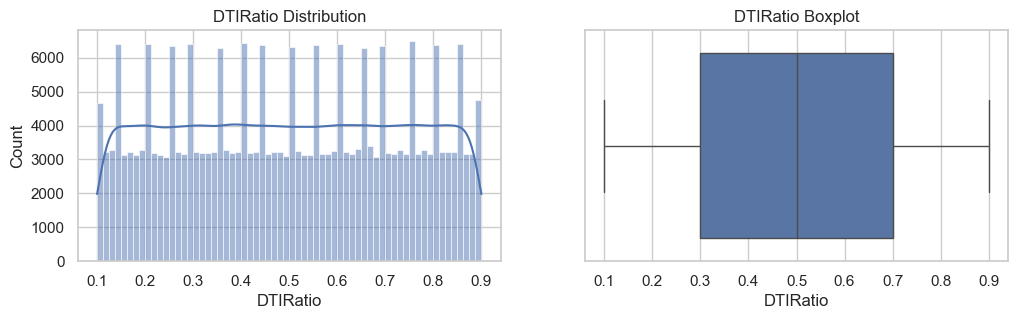

In [10]:
for col in num_cols:
    fig, axes = plt.subplots(1,2, figsize=(12,3))
    sns.histplot(df[col], kde=True, ax=axes[0])
    axes[0].set_title(f"{col} Distribution")

    sns.boxplot(x=df[col], ax=axes[1])
    axes[1].set_title(f"{col} Boxplot")

    plt.show()


Categorical Feature Distributions

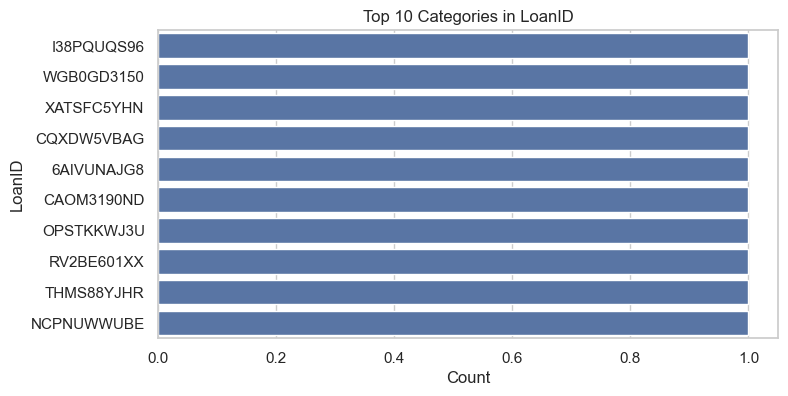

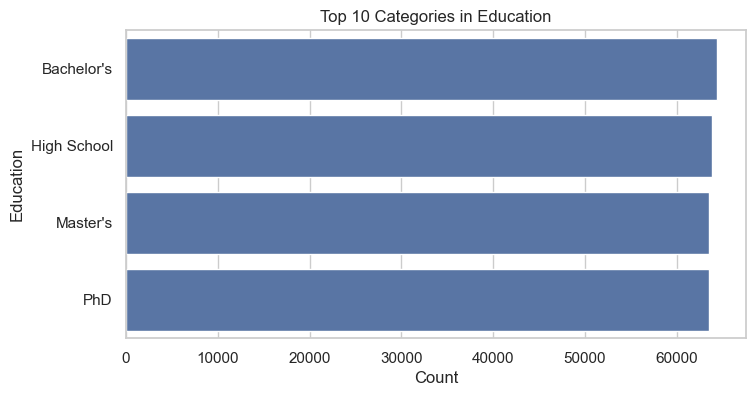

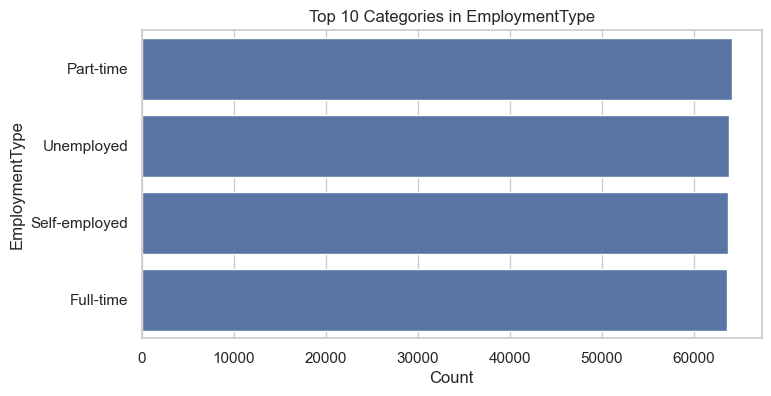

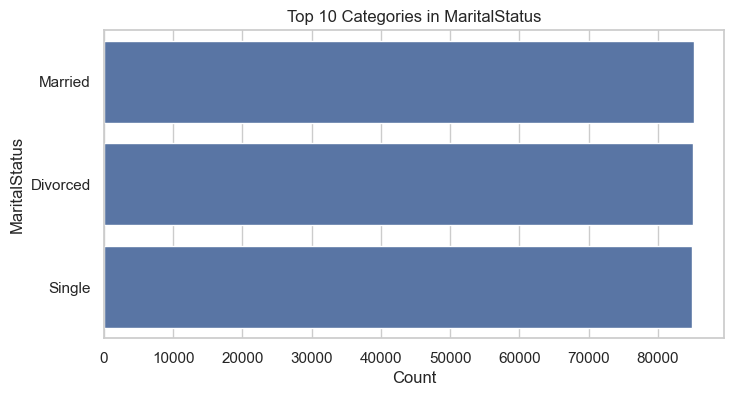

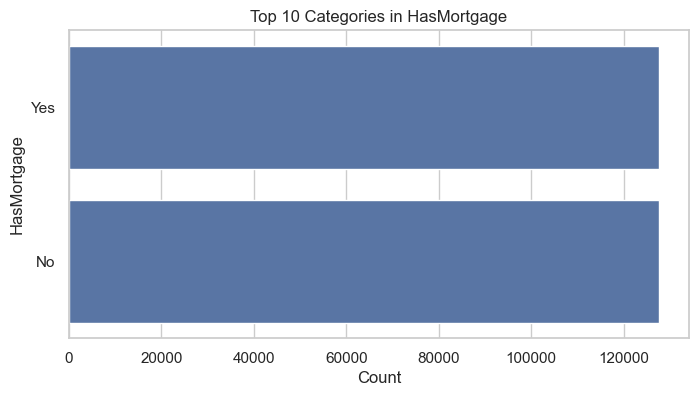

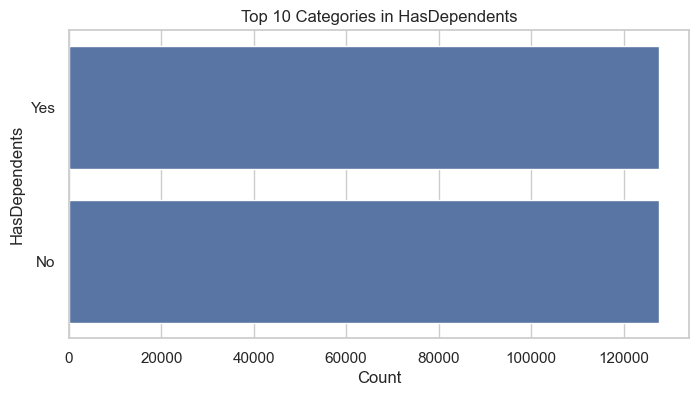

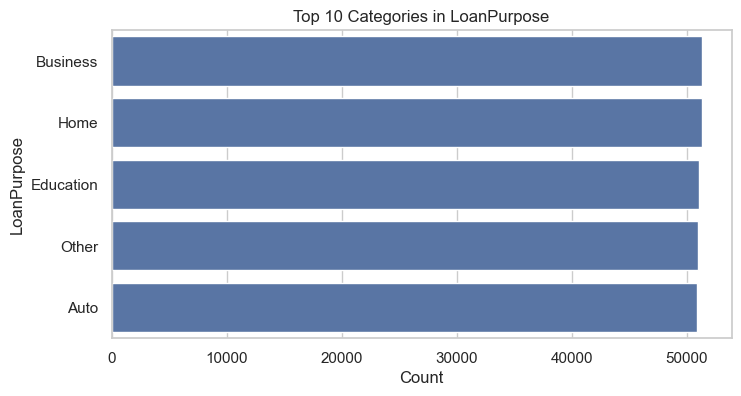

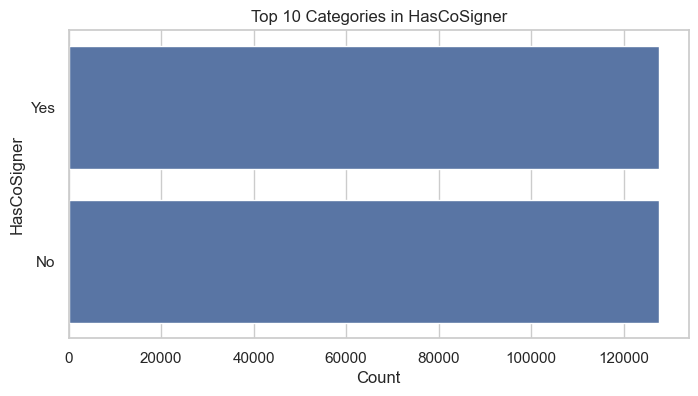

In [29]:
for col in cat_cols:
    plt.figure(figsize=(8,4))
    top10 = df[col].value_counts().nlargest(10)
    sns.barplot(x=top10.values, y=top10.index)
    plt.title(f"Top 10 Categories in {col}")
    plt.xlabel("Count")
    plt.ylabel(col)
    plt.show()


credit score by default

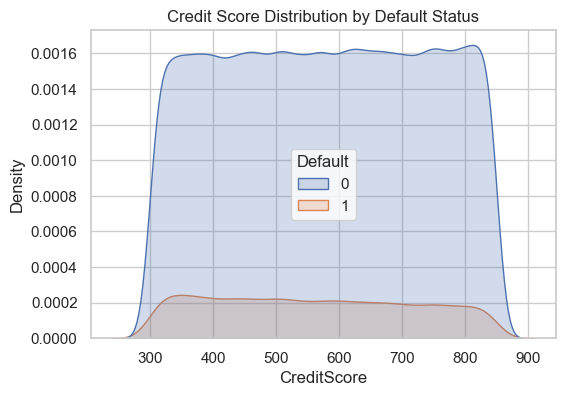

In [28]:
plt.figure(figsize=(6,4))
sns.kdeplot(data=df, x='CreditScore', hue='Default', fill=True)
plt.title('Credit Score Distribution by Default Status')
plt.show()

Numerical vs Target

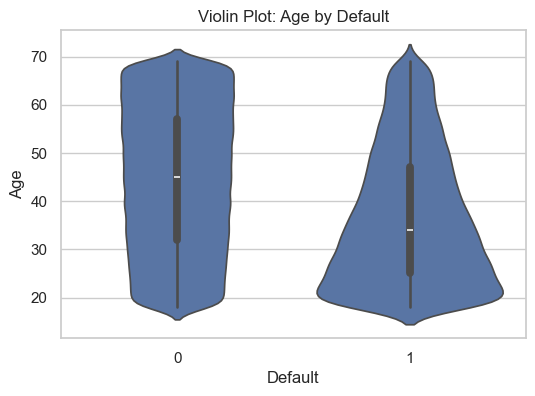

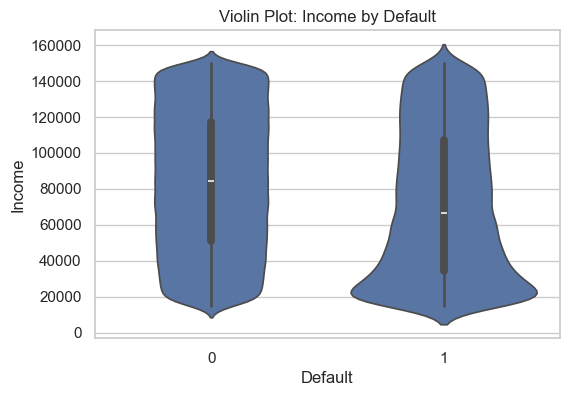

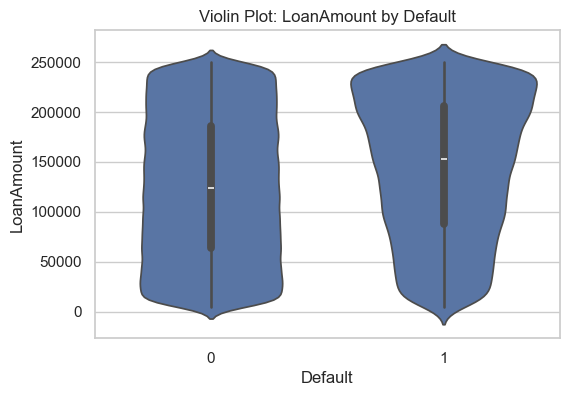

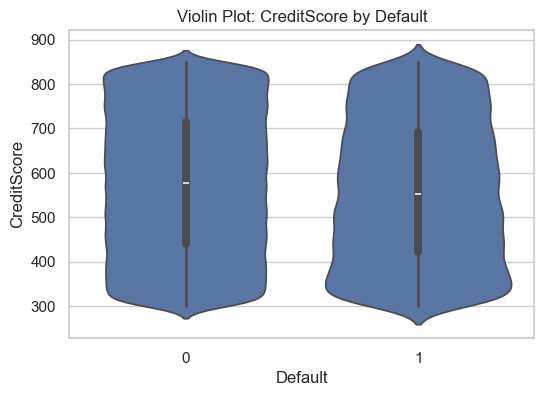

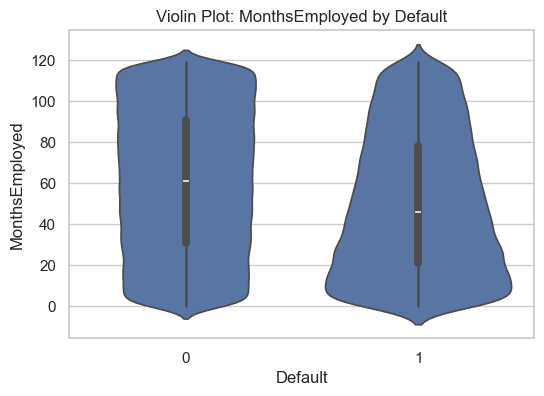

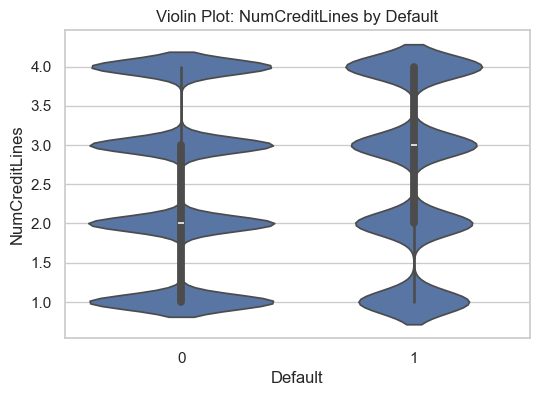

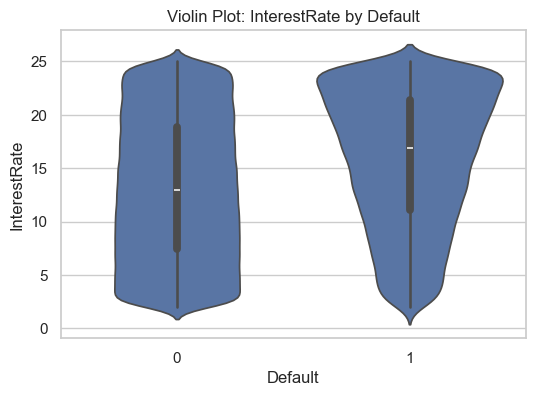

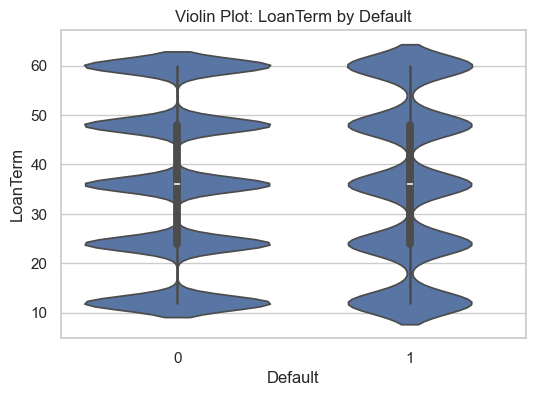

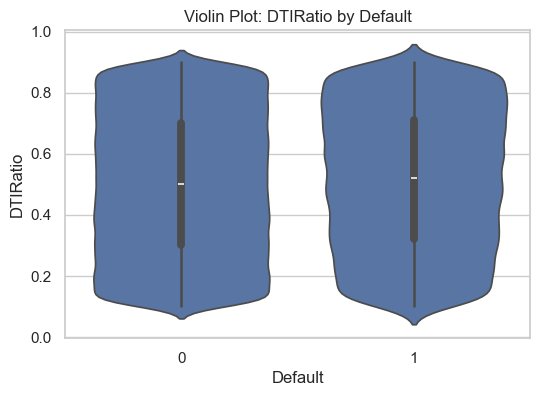

In [38]:
for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.violinplot(x=df['Default'], y=df[col])
    plt.title(f"Violin Plot: {col} by Default")
    plt.show()


Categorical vs Target

<Figure size 800x400 with 0 Axes>

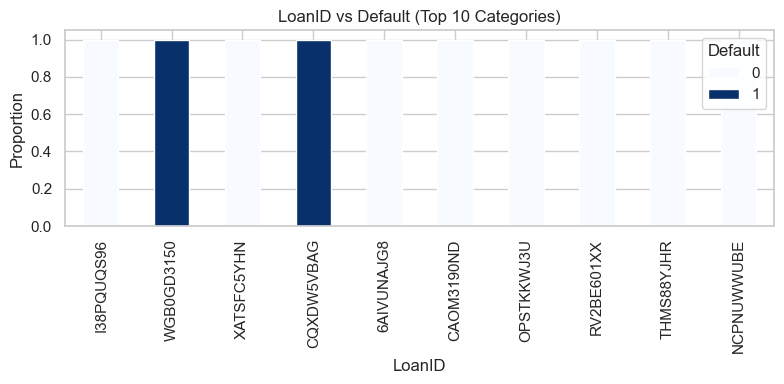

<Figure size 800x400 with 0 Axes>

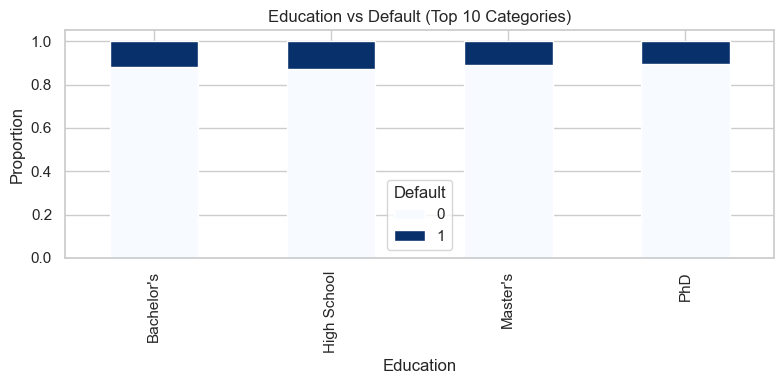

<Figure size 800x400 with 0 Axes>

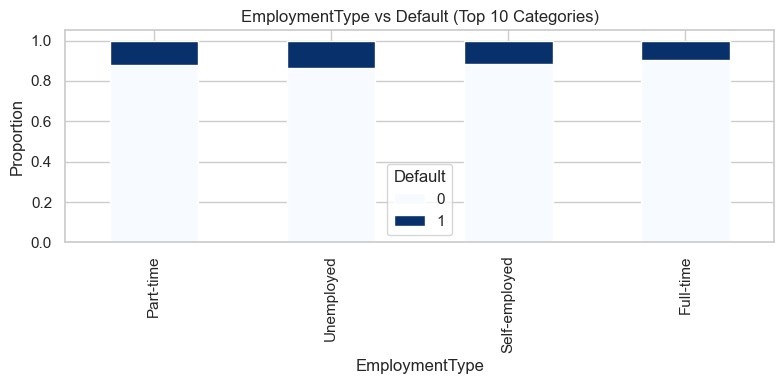

<Figure size 800x400 with 0 Axes>

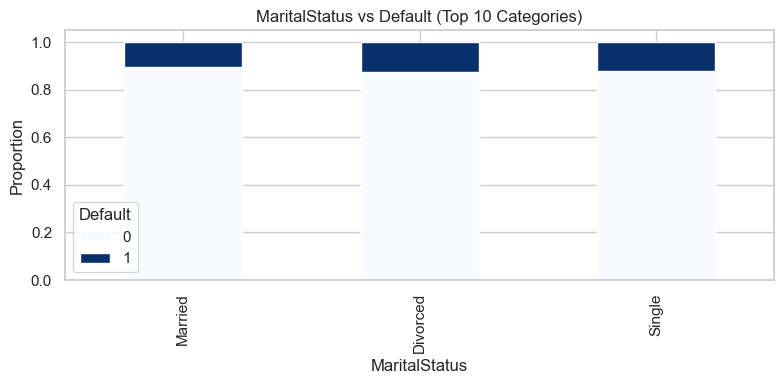

<Figure size 800x400 with 0 Axes>

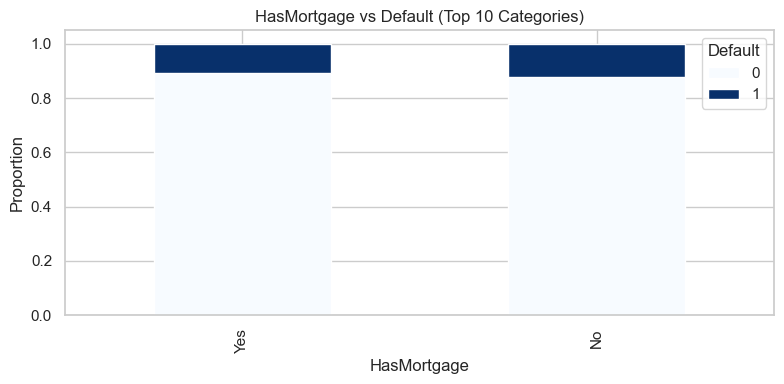

<Figure size 800x400 with 0 Axes>

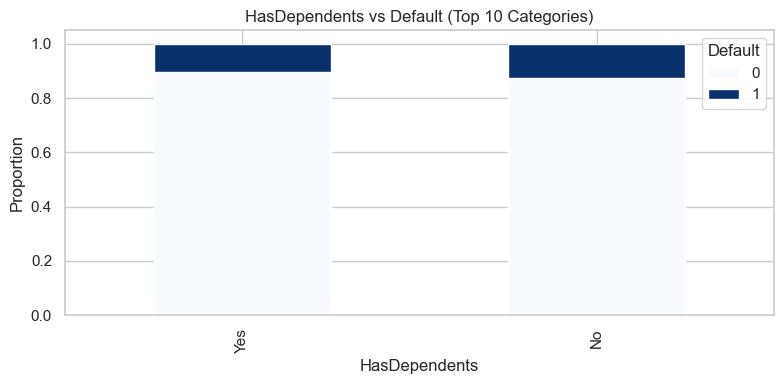

<Figure size 800x400 with 0 Axes>

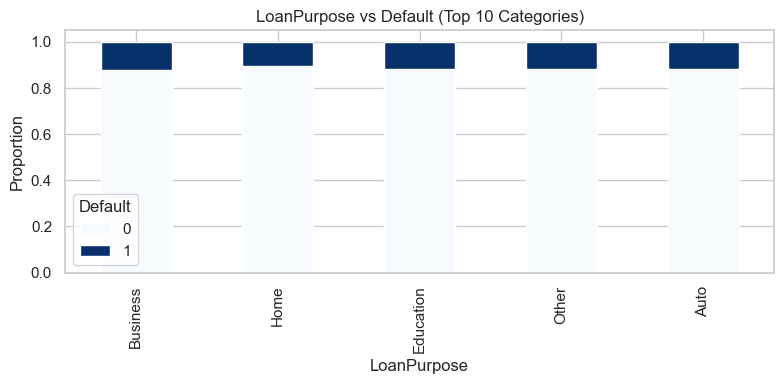

<Figure size 800x400 with 0 Axes>

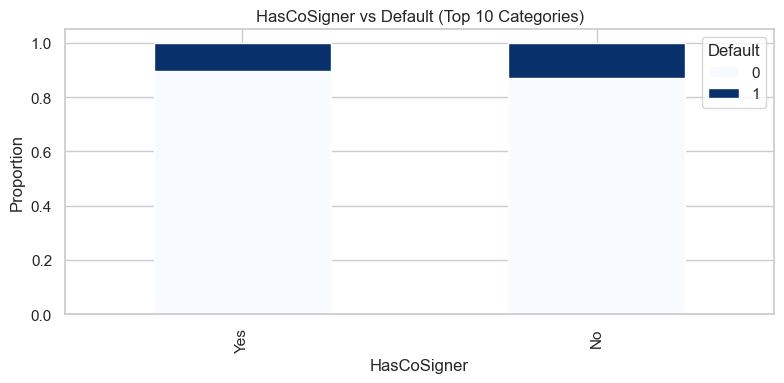

In [41]:
for col in cat_cols:
    plt.figure(figsize=(8,4))
    top10 = df[col].value_counts().nlargest(10).index
    ct = pd.crosstab(df[col], df[target_col], normalize="index").loc[top10]

    ct.plot(kind="bar", stacked=True, figsize=(8,4), colormap="Blues")
    plt.title(f"{col} vs Default (Top 10 Categories)")
    plt.ylabel("Proportion")
    plt.tight_layout()
    plt.show()


Age Distribution by Default (Histogram Overlay)

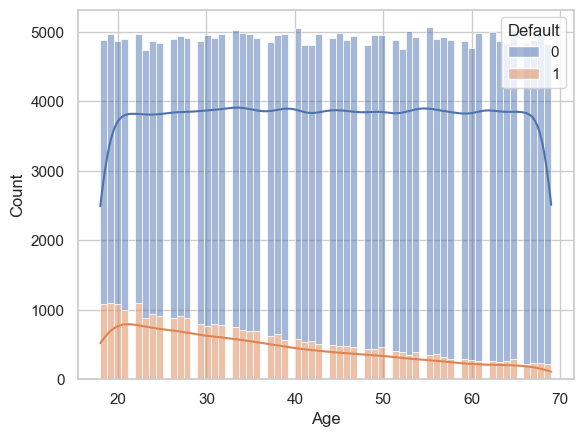

In [42]:
sns.histplot(data=df, x='Age', hue='Default', kde=True, multiple="stack")
plt.show()


In [ ]:
for col in cat_cols:
    print(df.groupby(col)[target_col].mean().sort_values(ascending=False).head(10))

LoanID
VAHCEX53CD    1.0
N1414OHK33    1.0
5MQKAJ857B    1.0
5MQP65AN7C    1.0
ERFDZZUPXH    1.0
V2QXY3X3LU    1.0
5MRUPCJ8ZZ    1.0
5MRUYID5IQ    1.0
V2QQBNUR48    1.0
ERES4L91F2    1.0
Name: Default, dtype: float64
Education
High School    0.128789
Bachelor's     0.121011
Master's       0.108717
PhD            0.105860
Name: Default, dtype: float64
EmploymentType
Unemployed       0.135529
Part-time        0.119652
Self-employed    0.114620
Full-time        0.094634
Name: Default, dtype: float64
MaritalStatus
Divorced    0.125328
Single      0.119124
Married     0.103972
Name: Default, dtype: float64
HasMortgage
No     0.123451
Yes    0.108806
Name: Default, dtype: float64
HasDependents
No     0.127244
Yes    0.105024
Name: Default, dtype: float64
LoanPurpose
Business     0.123260
Auto         0.118814
Education    0.118381
Other        0.117885
Home         0.102348
Name: Default, dtype: float64
HasCoSigner
No     0.128661
Yes    0.103601
Name: Default, dtype: float64


Correlation Heatmap

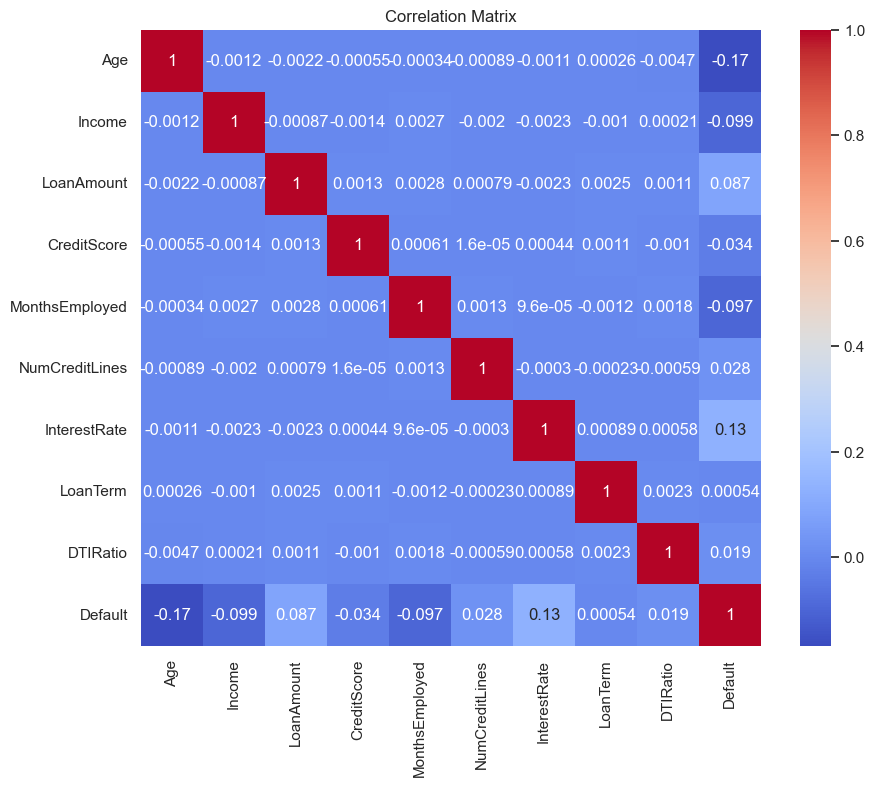

In [12]:
plt.figure(figsize=(10,8))
sns.heatmap(df[num_cols + ["Default"]].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()


Define Preprocessing Pipeline

In [13]:
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy="median")),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy="most_frequent")),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, num_cols),
    ('cat', categorical_transformer, cat_cols)
])


Outlier Detection with Z-Score / IQR

In [33]:
from scipy.stats import zscore

df_z = df[num_cols].apply(zscore)
(df_z.abs() > 3).sum()


Age               0
Income            0
LoanAmount        0
CreditScore       0
MonthsEmployed    0
NumCreditLines    0
InterestRate      0
LoanTerm          0
DTIRatio          0
dtype: int64

Bivariate Plots (Age vs Income vs Default)

KDE Plots for Distribution Comparison

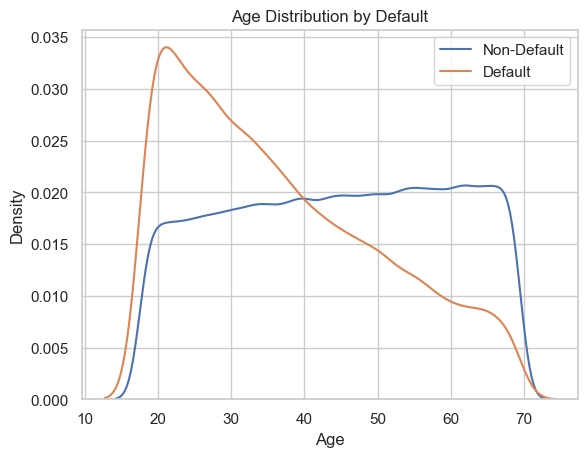

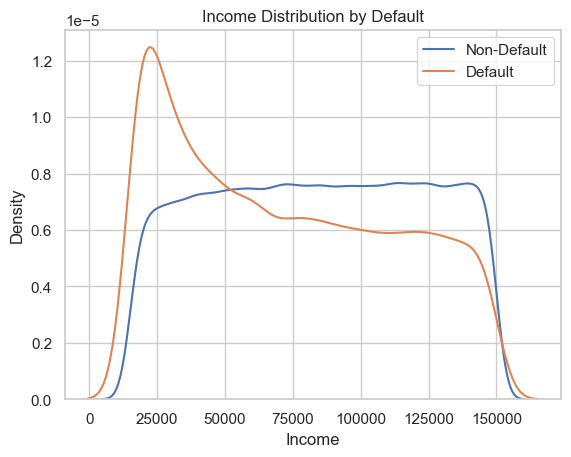

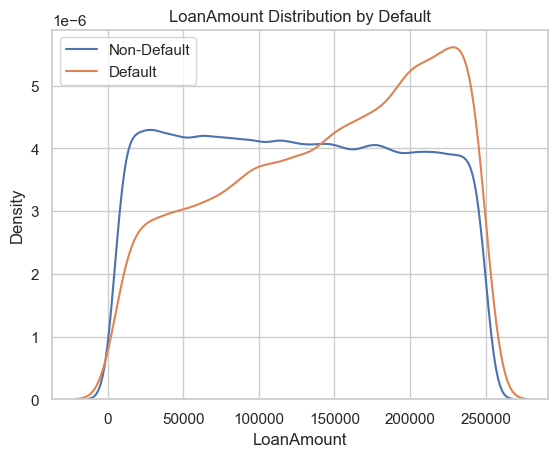

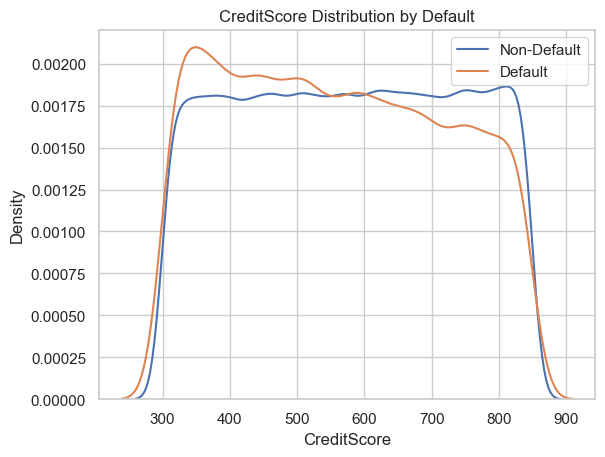

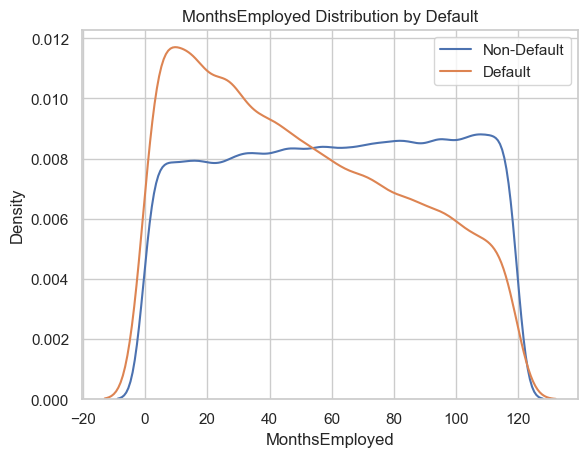

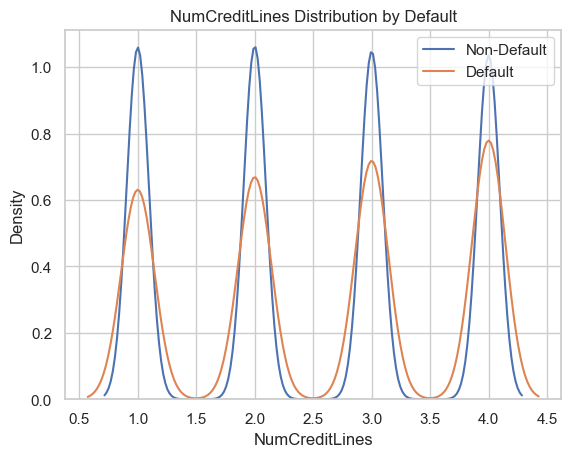

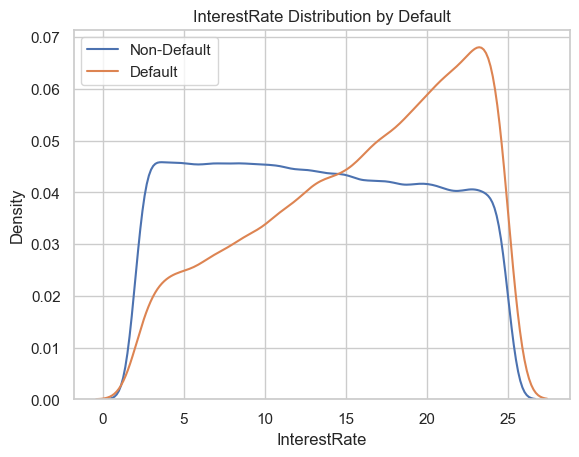

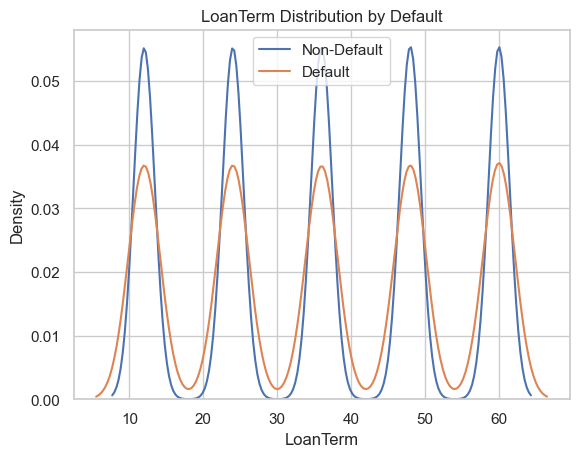

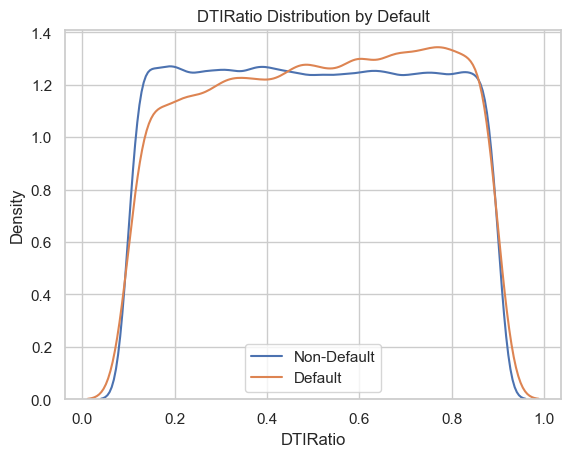

In [35]:
for col in num_cols:
    sns.kdeplot(df[df['Default']==0][col], label="Non-Default")
    sns.kdeplot(df[df['Default']==1][col], label="Default")
    plt.title(f"{col} Distribution by Default")
    plt.legend()
    plt.show()


Relationship Between Credit Score & Default (Line Plot)

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_14648\2934201951.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(pd.cut(df['CreditScore'], 10))['Default'].mean().plot(kind='line', marker='o')


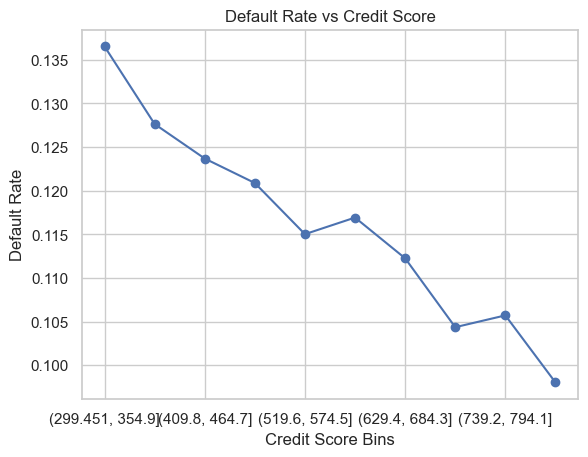

In [44]:
df.groupby(pd.cut(df['CreditScore'], 10))['Default'].mean().plot(kind='line', marker='o')
plt.title("Default Rate vs Credit Score")
plt.ylabel("Default Rate")
plt.xlabel("Credit Score Bins")
plt.show()


Loan-To-Income Ratio vs Default Rate

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_14648\3618726496.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(pd.qcut(df['LoanToIncome'], 10))['Default'].mean().plot(kind='bar')


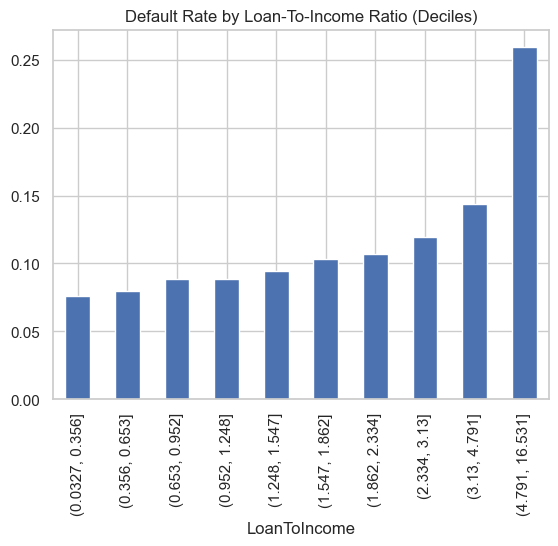

In [45]:
df.groupby(pd.qcut(df['LoanToIncome'], 10))['Default'].mean().plot(kind='bar')
plt.title("Default Rate by Loan-To-Income Ratio (Deciles)")
plt.show()


BEST GRAPH FOR CREDIT RISK ANALYSIS

 Employment Stability vs Default

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_14648\2911921932.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(pd.qcut(df['EmploymentStability'], 10))['Default'].mean().plot(kind='line', marker='o')


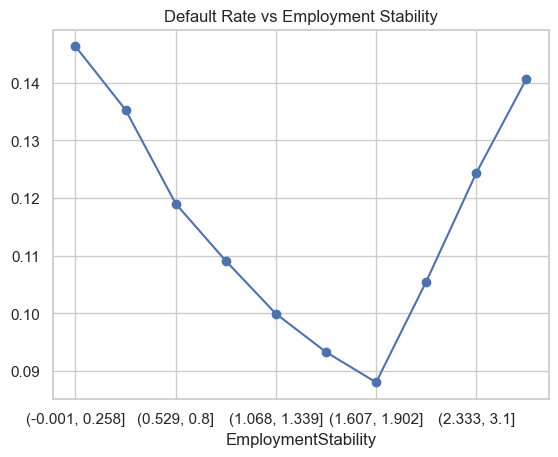

In [46]:
df.groupby(pd.qcut(df['EmploymentStability'], 10))['Default'].mean().plot(kind='line', marker='o')
plt.title("Default Rate vs Employment Stability")
plt.show()


Train/Test Split

In [14]:
X = df.drop(columns=[target_col])
y = df[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train.shape, X_test.shape


((204277, 17), (51070, 17))

SMOTE Oversampling

In [15]:
smote = SMOTE(random_state=42)


Model Pipelines

Logistic Regression

In [16]:
pipe_lr = ImbPipeline(steps=[
    ('preprocess', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('clf', LogisticRegression(max_iter=1000))
])


Decision Tree

In [17]:
pipe_dt = ImbPipeline(steps=[
    ('preprocess', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('clf', DecisionTreeClassifier(random_state=42))
])


Random Forest

In [18]:
pipe_rf = ImbPipeline(steps=[
    ('preprocess', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('clf', RandomForestClassifier(random_state=42, n_jobs=-1))
])


XGBoost

In [19]:
pipe_xgb = ImbPipeline(steps=[
    ('preprocess', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('clf', xgb.XGBClassifier(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.9,
        colsample_bytree=0.7,
        eval_metric="logloss"
    ))
])


Train Models

In [20]:
models = {
    "Logistic Regression": pipe_lr,
    "Decision Tree": pipe_dt,
    "Random Forest": pipe_rf,
    "XGBoost": pipe_xgb
}

for name, model in models.items():
    model.fit(X_train, y_train)
    print(f"{name} — Training Completed")


Logistic Regression — Training Completed
Decision Tree — Training Completed
Random Forest — Training Completed
XGBoost — Training Completed


Model Evaluation Function

In [21]:
def evaluate(model, X_test, y_test):
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:,1]

    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred))
    print("Recall:", recall_score(y_test, y_pred))
    print("F1-Score:", f1_score(y_test, y_pred))
    print("ROC-AUC:", roc_auc_score(y_test, y_proba))
    
    print("\nClassification Report:\n", classification_report(y_test, y_pred))
    
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap="Blues")
    plt.title("Confusion Matrix")
    plt.show()


Evaluate All Models

===== Logistic Regression =====
Accuracy: 0.8228509888388487
Precision: 0.31
Recall: 0.428595515090204
F1-Score: 0.35977637817564223
ROC-AUC: 0.753186045618381

Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.87      0.90     45139
           1       0.31      0.43      0.36      5931

    accuracy                           0.82     51070
   macro avg       0.62      0.65      0.63     51070
weighted avg       0.85      0.82      0.83     51070



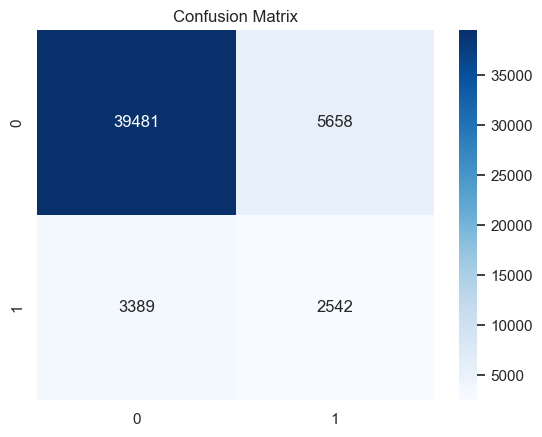




===== Decision Tree =====
Accuracy: 0.8343450166438222
Precision: 0.25799043062200955
Recall: 0.2272803911650649
F1-Score: 0.2416636787378989
ROC-AUC: 0.5706950705243787

Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.91      0.91     45139
           1       0.26      0.23      0.24      5931

    accuracy                           0.83     51070
   macro avg       0.58      0.57      0.57     51070
weighted avg       0.83      0.83      0.83     51070



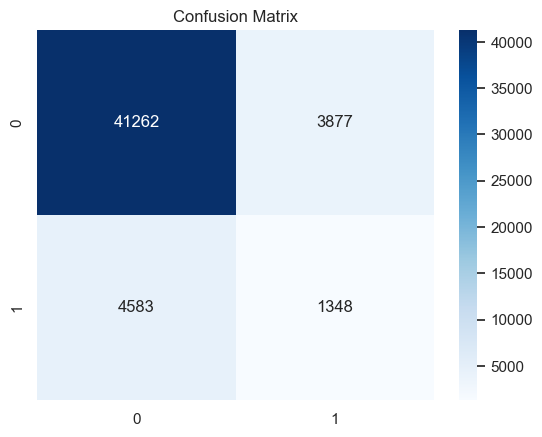




===== Random Forest =====
Accuracy: 0.8840023497160759
Precision: 0.5507246376811594
Recall: 0.0064070139942674085
F1-Score: 0.012666666666666666
ROC-AUC: 0.7199622105097356

Classification Report:
               precision    recall  f1-score   support

           0       0.88      1.00      0.94     45139
           1       0.55      0.01      0.01      5931

    accuracy                           0.88     51070
   macro avg       0.72      0.50      0.48     51070
weighted avg       0.85      0.88      0.83     51070



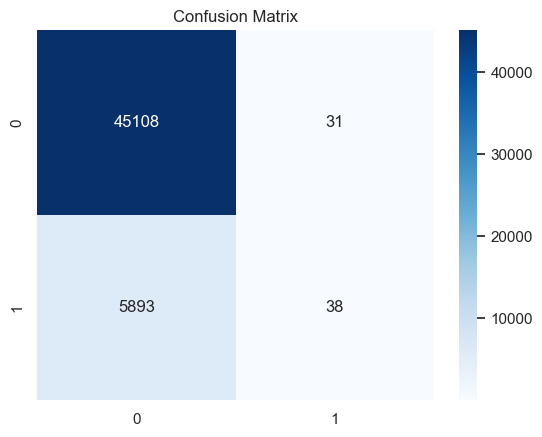




===== XGBoost =====
Accuracy: 0.8869394948110436
Precision: 0.5994930291508238
Recall: 0.07975046366548642
F1-Score: 0.14077380952380952
ROC-AUC: 0.7562609945101141

Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.99      0.94     45139
           1       0.60      0.08      0.14      5931

    accuracy                           0.89     51070
   macro avg       0.75      0.54      0.54     51070
weighted avg       0.86      0.89      0.85     51070



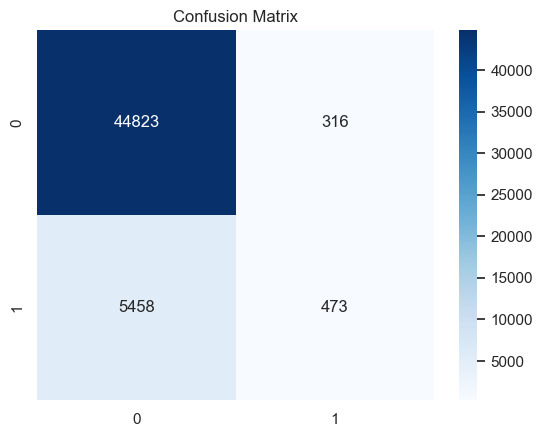

In [22]:
for name, model in models.items():
    print(f"===== {name} =====")
    evaluate(model, X_test, y_test)
    print("\n\n")


ROC Curve

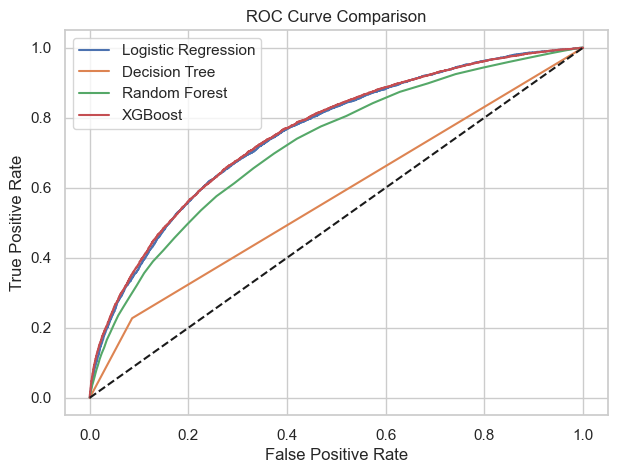

In [23]:
plt.figure(figsize=(7,5))

for name, model in models.items():
    y_proba = model.predict_proba(X_test)[:,1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    plt.plot(fpr, tpr, label=f"{name}")

plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()


Feature Importance (Random Forest / XGBoost Only)

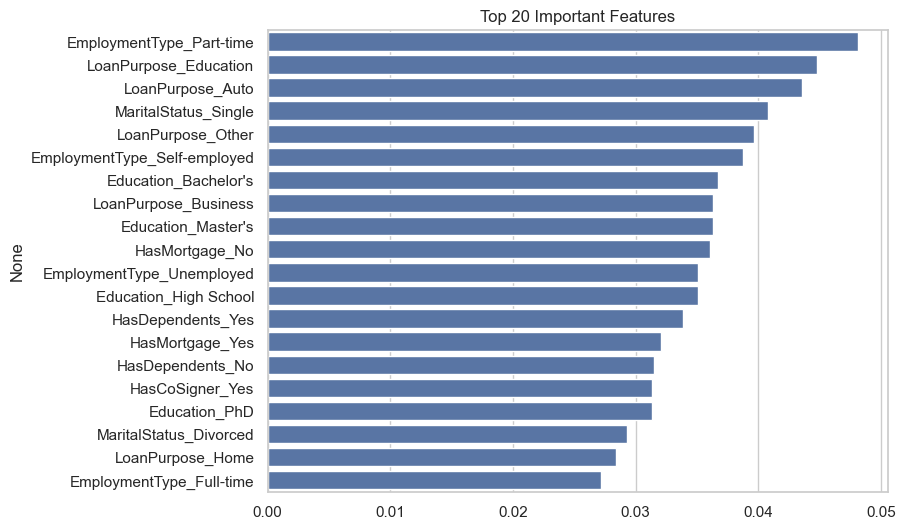

In [24]:
best_model = pipe_xgb  # you can choose pipe_rf too

best_model.fit(X_train, y_train)

preprocessor.fit(X_train)
ohe = preprocessor.named_transformers_["cat"].named_steps["onehot"]

feature_names = num_cols + list(ohe.get_feature_names_out(cat_cols))

importances = best_model.named_steps["clf"].feature_importances_
fi = pd.Series(importances, index=feature_names).sort_values(ascending=False).head(20)

plt.figure(figsize=(8,6))
sns.barplot(x=fi.values, y=fi.index)
plt.title("Top 20 Important Features")
plt.show()


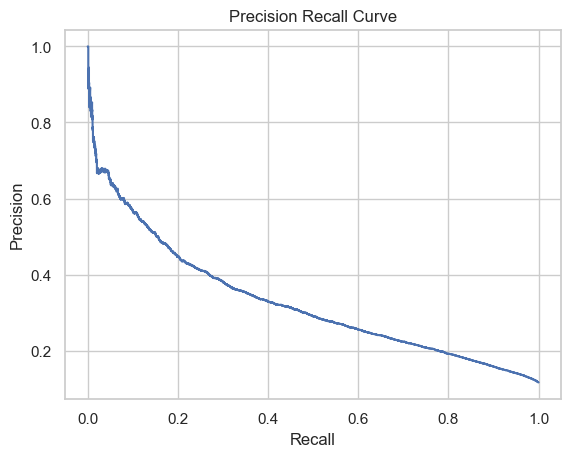

In [48]:
precision, recall, thresholds = precision_recall_curve(y_test, y_proba)

plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision Recall Curve")
plt.show()

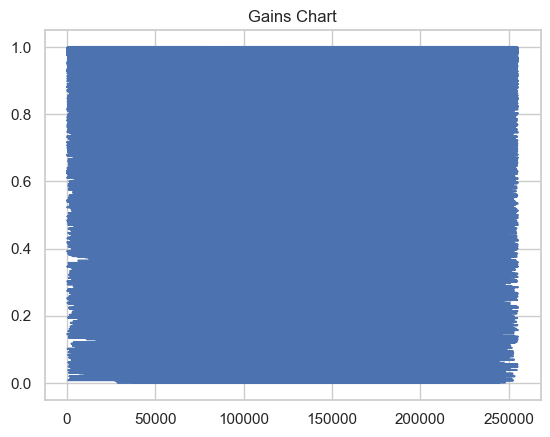

In [49]:
df_lift = pd.DataFrame({"y": y_test, "proba": y_proba})
df_lift = df_lift.sort_values("proba", ascending=False)
df_lift["cum_default"] = df_lift["y"].cumsum()
df_lift["cum_default_rate"] = df_lift["cum_default"] / df_lift["cum_default"].max()

plt.plot(df_lift["cum_default_rate"])
plt.title("Gains Chart")
plt.show()


In [52]:
from scipy.stats import ks_2samp

ks_stat = ks_2samp(y_proba[y_test==1], y_proba[y_test==0])
ks_stat


KstestResult(statistic=0.3816610248082536, pvalue=0.0, statistic_location=0.13514604, statistic_sign=-1)

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_14648\3756053239.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_risk.groupby("RiskBand")["Default"].mean().plot(kind='bar', color='purple')


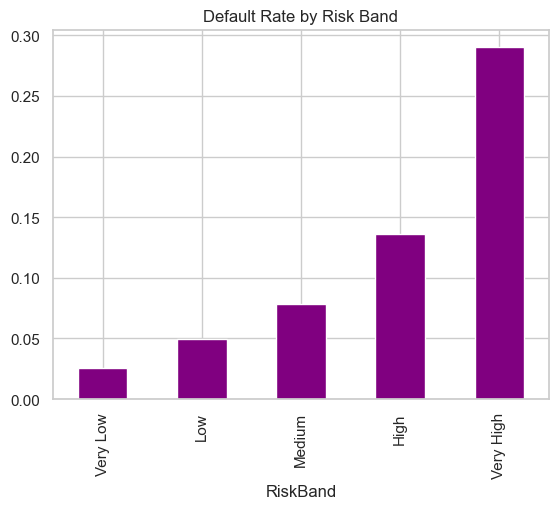

In [53]:
df_risk = pd.DataFrame({"Score": y_proba, "Default": y_test})
df_risk["RiskBand"] = pd.qcut(df_risk["Score"], 5, labels=["Very Low","Low","Medium","High","Very High"])

df_risk.groupby("RiskBand")["Default"].mean().plot(kind='bar', color='purple')
plt.title("Default Rate by Risk Band")
plt.show()


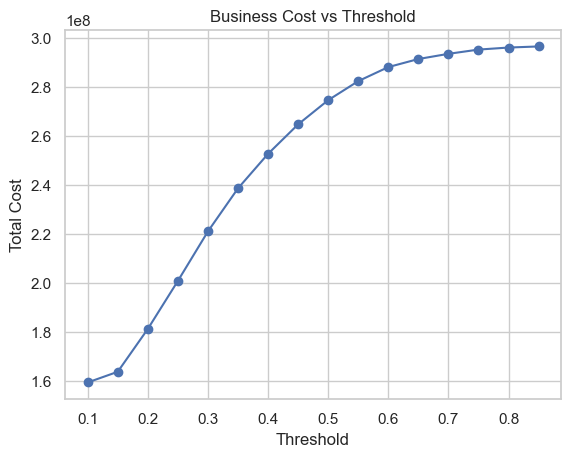

In [54]:
cost_FN = 50000  # default loss
cost_FP = 5000   # missed good customer

thresholds = np.arange(0.1, 0.9, 0.05)
costs = []

for t in thresholds:
    pred = (y_proba >= t).astype(int)
    cm = confusion_matrix(y_test, pred)
    FN = cm[1][0]
    FP = cm[0][1]
    total_cost = FN*cost_FN + FP*cost_FP
    costs.append(total_cost)

plt.plot(thresholds, costs, marker='o')
plt.title("Business Cost vs Threshold")
plt.xlabel("Threshold")
plt.ylabel("Total Cost")
plt.show()
